# Подготовка датасета Lenta.ru для задачи novelty detection

Цель данного ноутбука — подготовить датасет для финального проекта **Semantic News Novelty**.

Проектная постановка:

> Система получает поток новостей, группирует публикации по сюжетам и оценивает, добавляет ли новая публикация существенную информацию к уже известному контексту сюжета.

В рамках этой домашней работы ноутбук делает не обучение финальной модели, а именно подготовку и анализ данных:

1. скачивает и распаковывает датасет Lenta.ru;
2. приводит данные к единой схеме;
3. выполняет базовый EDA;
4. проверяет качество и чистоту данных;
5. формирует очищенный датасет новостей;
6. формирует заготовку выборки для дальнейшей ручной разметки novelty;
7. описывает стратегию разметки и валидации.

Важно: Lenta.ru — это хороший корпус для первичного EDA, векторизации и подбора алгоритмов кластеризации, но в нём нет готовой разметки "существенная новая информация / дубль". Поэтому novelty-разметку нужно формировать отдельно на основе кандидатных пар или кандидатных публикаций внутри сюжетных групп.

## 1. Импорты и настройки

Датасет Lenta.ru достаточно большой: около сотен мегабайт в сжатом виде и существенно больше после распаковки. 
Поэтому в настройках ниже можно ограничить количество строк для быстрого локального запуска.

По умолчанию работаем прямо из архива, не распаковывая. Если хочется (для скорости) распаковать, поставить 
```python
DECOMPRESS_FULL_CSV = True
```

Для финального прогона можно поставить:
```python
LOAD_FULL_DATASET = True
MAX_ROWS = None
```

In [15]:
from pathlib import Path
import os
import bz2
import shutil
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

In [16]:
# Основные пути
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PREPARED_DIR = DATA_DIR / "prepared"

for path in [RAW_DIR, PREPARED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Официальный GitHub Release датасета yutkin/Lenta.Ru-News-Dataset.
# Если ссылка изменится, можно скачать файл вручную из Releases проекта и положить в RAW_DIR
LENTA_BZ2_URL = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.1/lenta-ru-news.csv.bz2"

LENTA_BZ2_PATH = RAW_DIR / "lenta-ru-news.csv.bz2"
LENTA_CSV_PATH = RAW_DIR / "lenta-ru-news.csv"

# Для быстрого запуска ноутбука можно читать только часть строк. Но надо учесть что оно по годам отсортировано, и выборка будет "древняя"
LOAD_FULL_DATASET = False
MAX_ROWS = 100_000

# Если True — явно распакует .bz2 в .csv. Это может занять время и потребовать несколько ГБ места.
# Для pandas это не обязательно: read_csv умеет читать .bz2 напрямую.
DECOMPRESS_FULL_CSV = False

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PREPARED_DIR)

PROJECT_ROOT: E:\ML\Projects\Git\news-flow-analysis
RAW_DIR: E:\ML\Projects\Git\news-flow-analysis\data\raw
PROCESSED_DIR: E:\ML\Projects\Git\news-flow-analysis\data\prepared


## 2. Скачивание и распаковка Lenta.ru

Используется публичный набор новостей Lenta.ru. В исходном датасете есть поля:

- `url` — ссылка на публикацию;
- `title` — заголовок;
- `text` — текст новости;
- `topic` — широкая тематическая рубрика;
- `tags` — дополнительные теги;
- `date` — дата публикации.

Для нашей задачи для векторизации важны прежде всего `title`, `text`, `date`, `topic` и `url`.

In [17]:
def download_file(url: str, output_path: Path, chunk_size: int = 1024 * 1024) -> None:
    """Скачивает файл по URL, если его ещё нет локально."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Файл уже существует: {output_path} ({output_path.stat().st_size / 1024**2:.1f} MB)")
        return

    print(f"Скачиваем: {url}")
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        downloaded = 0
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        pct = downloaded / total * 100
                        print(f"\r{downloaded / 1024**2:.1f} / {total / 1024**2:.1f} MB ({pct:.1f}%)", end="")
    print(f"\nГотово: {output_path}")

In [18]:
# Если интернет в окружении доступен, эта ячейка скачает датасет.
# Если нет — скачать lenta-ru-news.csv.bz2 вручную и положить в DATA_RAW (ссылка есть выше)
try:
    download_file(LENTA_BZ2_URL, LENTA_BZ2_PATH)
except Exception as e:
    print("Не удалось скачать файл автоматически.")
    print(f"Положите lenta-ru-news.csv.bz2 вручную в папку {RAW_DIR} и перезапустите ноутбук.")
    print("Ошибка:", repr(e))

Файл уже существует: E:\ML\Projects\Git\news-flow-analysis\data\raw\lenta-ru-news.csv.bz2 (330.0 MB)


In [19]:
def decompress_bz2(input_path: Path, output_path: Path) -> None:
    """Явно распаковывает .bz2 в .csv."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Распакованный CSV уже существует: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")
        return

    if not input_path.exists():
        raise FileNotFoundError(f"Не найден архив: {input_path}")

    print(f"Распаковываем {input_path} -> {output_path}")
    with bz2.open(input_path, "rb") as src, open(output_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    print(f"Готово: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")

if DECOMPRESS_FULL_CSV:
    decompress_bz2(LENTA_BZ2_PATH, LENTA_CSV_PATH)
else:
    print("Явная распаковка отключена. pandas будет читать .bz2 напрямую.")

Явная распаковка отключена. pandas будет читать .bz2 напрямую.


## 3. Загрузка данных

Для экономии места и времени можно читать `.bz2` напрямую. Если включена явная распаковка, читаем `.csv`.
Оцениваем shape, структуру данных

In [20]:
if LENTA_CSV_PATH.exists():
    input_path = LENTA_CSV_PATH
    compression = None
elif LENTA_BZ2_PATH.exists():
    input_path = LENTA_BZ2_PATH
    compression = "bz2"
else:
    raise FileNotFoundError("Не найден ни распакованный CSV, ни .bz2 архив Lenta.ru")

nrows = None if LOAD_FULL_DATASET else MAX_ROWS

raw_df = pd.read_csv(input_path, compression=compression, nrows=nrows)
print(raw_df.shape)
raw_df.head()

(100000, 6)


,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914/09/18


In [21]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     100000 non-null  str  
 1   title   100000 non-null  str  
 2   text    100000 non-null  str  
 3   topic   100000 non-null  str  
 4   tags    99999 non-null   str  
 5   date    100000 non-null  str  
dtypes: str(6)
memory usage: 226.5 MB


## 4. Приведение к единой схеме, препроцессинг данных

Дальше используем единую схему колонок (если будет другой датасет, будем приводить к аналогичной):

- `news_id` — внутренний идентификатор;
- `url` — ссылка;
- `title` — заголовок;
- `text` — текст;
- `topic` — широкая рубрика;
- `tags` — теги;
- `published_at` — дата публикации;
- `text_length` — длина текста в символах;
- `text_num_words` — число слов в тексте.

Колонки `title`, `text`, `published_at` считаем обязательными в датасете - так как без них провести анализ проблематично

In [22]:
def normalize_lenta_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # В датасете Lenta.ru дата обычно называется date.
    if "date" in df.columns and "published_at" not in df.columns:
        df = df.rename(columns={"date": "published_at"})

    required_cols = ["title", "text", "published_at"]
    missing_required = [col for col in required_cols if col not in df.columns]
    if missing_required:
        raise ValueError(f"В датасете не найдены обязательные колонки: {missing_required}")

    if "url" not in df.columns:
        df["url"] = np.nan
    if "topic" not in df.columns:
        df["topic"] = "unknown"
    if "tags" not in df.columns:
        df["tags"] = "unknown"

    df["news_id"] = np.arange(len(df))
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

    df["title"] = df["title"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["topic"] = df["topic"].fillna("unknown").astype(str)
    df["tags"] = df["tags"].fillna("unknown").astype(str)

    df["text_length"] = df["text"].str.len()
    df["text_num_words"] = df["text"].str.split().str.len()
    df["title_length"] = df["title"].str.len()
    df["title_num_words"] = df["title"].str.split().str.len() 

    df["model_text"] = (df["title"].fillna("").astype(str) + ". " + df["text"].fillna("").astype(str)) #полный текст для токенизации
    df["model_length"] = df["model_text"].str.len()
    df["model_num_words"] = df["model_text"].str.split().str.len() 

    return df

news_df = normalize_lenta_columns(raw_df)
news_df.head()

,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4,"1914. Бульдог-гонец под Льежем . Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший ...",736,104
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6,"1914. Под Люблином пойман швабский зверь. Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший к...",796,121


## 5. EDA - первичный анализ качества данных

На этом этапе проверяем то, что наиболее важно для консистентности данных для модели:

- есть ли пропуски в ключевых полях;
- есть ли дубли;
- есть ли слишком короткие тексты;
- корректно ли распарсились даты;
- как распределены рубрики и источники;
- как распределены новости во времени.

In [23]:
print("Размер датасета:", news_df.shape)
news_df.head(3)

Размер датасета: (100000, 14)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267


In [24]:
#Cчитаем долю пропусков по каждому столбцу и показывает только те столбцы, где пропуски есть.
missing_share = news_df.isna().mean().sort_values(ascending=False)
missing_share[missing_share > 0]

Series([], dtype: float64)

In [25]:
quality_report = pd.DataFrame({
    "metric": [
        "Количество записей",
        "С пустым текстом",
        "С пустым заголовком",
        "С пустой датой",
        "Полных дублей",
        "Дублей текста",
        "Дублей URL",
        "Слишком короткие тексты (<20 слов)",
    ],
    "value": [
        len(news_df),
        (news_df["text"].str.strip() == "").sum(),
        (news_df["title"].str.strip() == "").sum(),
        news_df["published_at"].isna().sum(),
        news_df.duplicated().sum(),
        news_df["text"].duplicated().sum(),
        news_df.loc[news_df["url"].notna(), "url"].duplicated().sum(),
        (news_df["model_num_words"] < 20).sum(),
    ]
})
quality_report

,metric,value
0,Количество записей,100000
1,С пустым текстом,0
2,С пустым заголовком,0
3,С пустой датой,0
4,Полных дублей,0
5,Дублей текста,187
6,Дублей URL,11
7,Слишком короткие тексты (<20 слов),349


### Вывод по чистоте данных

Изначальная задача для последующей кластеризации и анализа - семантическая векторизация с последующей кластеризацией по таймлайну, и выделение "выбросов" из кластеров с учетом таймлайна, для нее критичны:

1. пустые тексты; - нечего векторизовать
2. некорректные даты; - потом как строить таймлайн?
3. полные дубли текстов; - это изначально одинаковые новости
4. слишком короткие публикации. - большой шанс некорректной векторизации

Вкратце: Пустые и очень короткие тексты дают нестабильные эмбеддинги. Некорректные даты мешают использовать временную логику, а дубли искажают оценку кластеризации и определение новизны.

## 6. Первичная очистка

Очистка для MVP намеренно простая: мы не делаем глубокую обработку признаков, лемматизацию или сложную фильтрацию. Главная цель — получить пригодный датафрейм новостей для дальнейшей векторизации и разметки.

In [26]:
def clean_news(df: pd.DataFrame, min_words: int = 20) -> pd.DataFrame:
    df = df.copy()

    before = len(df)

    df = df.dropna(subset=["published_at"])
    df = df[df["text"].str.strip() != ""]
    df = df[df["title"].str.strip() != ""]
    df = df[df["model_num_words"] >= min_words]

    # Удаляем полные текстовые дубли.
    df = df.drop_duplicates(subset=["text"])

    # Удаляем дубли URL
    if "url" in df.columns:
        df = df.sort_values("published_at")
        df = df.drop_duplicates(subset=["url"], keep="first")

    df = df.sort_values("published_at").reset_index(drop=True)
    df["news_id"] = np.arange(len(df))

    after = len(df)
    print(f"Было строк: {before}")
    print(f"Стало строк: {after}")
    print(f"Удалено строк: {before - after} ({(before - after) / before:.2%})")

    return df

clean_df = clean_news(news_df, min_words=20)
clean_df.head()

Было строк: 100000
Стало строк: 99636
Удалено строк: 364 (0.36%)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4,"1914. Бульдог-гонец под Льежем . Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший ...",736,104
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6,"1914. Под Люблином пойман швабский зверь. Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший к...",796,121


## 7. EDA - анализ после очистки

### 7.1 Длины текстов и заголовков

Слишком короткие тексты могут не содержать достаточного контекста, а слишком длинные будут обрезаться transformer-моделью.

In [ ]:
clean_df[["text_length", "text_num_words", "title_length", "title_num_words", "model_num_words"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

KeyError: "['model_text_num_words'] not in index"

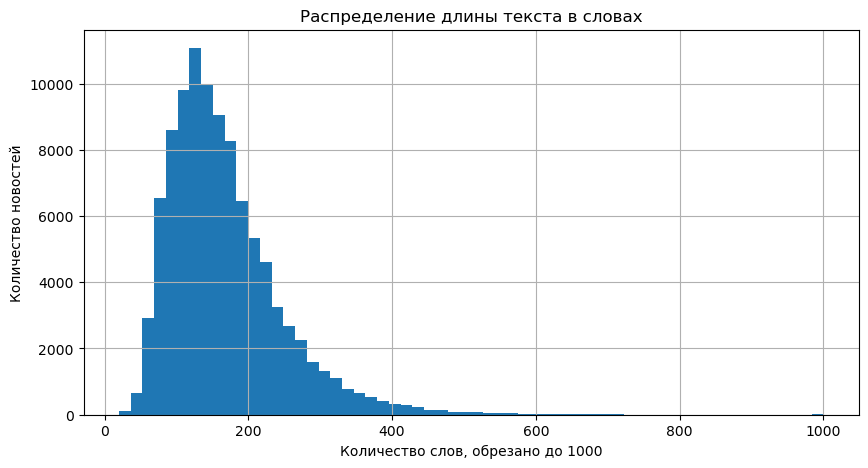

In [ ]:
plt.figure(figsize=(10, 5))
clip_text_display_at = 1000
clean_df["model_num_words"].clip(upper=clip_text_display_at).hist(bins=60)
plt.title("Распределение длины текста в словах")
plt.xlabel(f"Количество слов, обрезано до {clip_text_display_at}")
plt.ylabel("Количество новостей")
plt.show()

Вывод: тексты достаточно длинные, надо исследовать, насколько в (готовой) модели будут обрезаться тексты с учетом обрезки токенов при векторизации.

In [ ]:
#для проверки распределения грузим базовую модель токенизации
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

max_seq_length = model.max_seq_length
print("Максимальная длина токена в модели:",max_seq_length)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Максимальная длина токена в модели: 128


In [ ]:
token_lengths = []

for text in tqdm(clean_df["model_text"].fillna("").astype(str)):
    tokens = model.tokenizer(
        text,
        truncation=False,
        add_special_tokens=True
    )
    token_lengths.append(len(tokens["input_ids"]))

clean_df["token_length"] = token_lengths

  0%|          | 0/99636 [00:00<?, ?it/s]

In [ ]:
truncated_share = (clean_df["token_length"] > max_seq_length).mean()
print(f"Распределение количества токенов в записях, где длина превышает лимит модели ({max_seq_length})")
print(clean_df["token_length"].describe())
print(f"Доля записей, где длина превышает лимит модели ({max_seq_length}):", truncated_share)


Распределение количества токенов в записях, где длина превышает лимит модели (128)
count    99636.000000
mean       310.640100
std        150.893418
min         40.000000
25%        210.000000
50%        281.000000
75%        376.000000
max      13148.000000
Name: token_length, dtype: float64
Доля записей, где длина превышает лимит модели (128): 0.9685455056405315


Вывод: надо увеличивать. Что и делаем ниже.

In [ ]:
#Повторяем для 512
NEW_TOKEN_LENGTH = 512
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
model.max_seq_length = NEW_TOKEN_LENGTH
max_seq_length = model.max_seq_length
print("Максимальная длина токена в модели:",max_seq_length)
token_lengths = []

for text in tqdm(clean_df["model_text"].fillna("").astype(str)):
    tokens = model.tokenizer(
        text,
        truncation=False,
        add_special_tokens=True
    )
    token_lengths.append(len(tokens["input_ids"]))

clean_df["token_length"] = token_lengths
truncated_share = (clean_df["token_length"] > max_seq_length).mean()
print(f"Распределение количества токенов в записях, где длина превышает лимит модели ({max_seq_length})")
print(clean_df["token_length"].describe())
print(f"Доля записей, где длина превышает лимит модели ({max_seq_length}):", truncated_share)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Максимальная длина токена в модели: 512


  0%|          | 0/99636 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (603 > 512). Running this sequence through the model will result in indexing errors


Распределение количества токенов в записях, где длина превышает лимит модели (512)
count    99636.000000
mean       310.640100
std        150.893418
min         40.000000
25%        210.000000
50%        281.000000
75%        376.000000
max      13148.000000
Name: token_length, dtype: float64
Доля записей, где длина превышает лимит модели (512): 0.08518005540166206


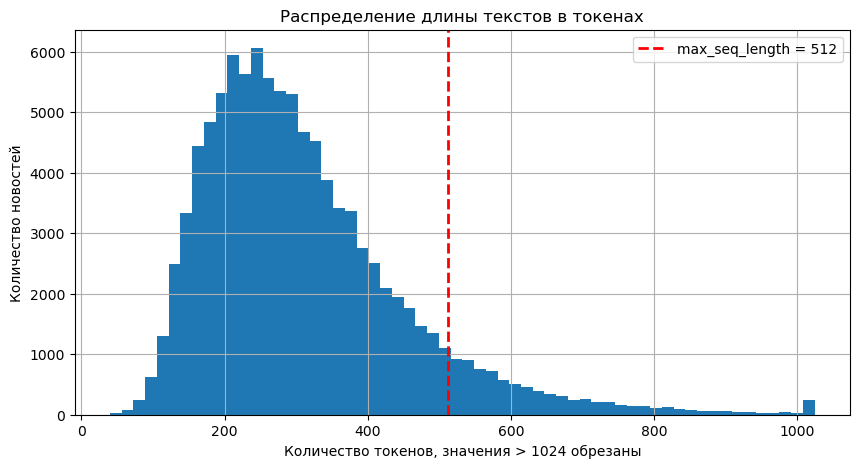

In [ ]:
plt.figure(figsize=(10, 5))

clip_at = max_seq_length * 2

clean_df["token_length"].clip(upper=clip_at).hist(bins=60)

plt.axvline(
    max_seq_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"max_seq_length = {max_seq_length}"
)

plt.title("Распределение длины текстов в токенах")
plt.xlabel(f"Количество токенов, значения > {clip_at} обрезаны")
plt.ylabel("Количество новостей")
plt.legend()
plt.show()

In [ ]:
e = (clean_df["token_length"] > max_seq_length).mean()

print(f"Доля текстов длиннее max_seq_length={max_seq_length}: {truncated_share:.2%}")
clean_df["token_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

Доля текстов длиннее max_seq_length=512: 8.52%


count    99636.000000
mean       310.640100
std        150.893418
min         40.000000
25%        210.000000
50%        281.000000
75%        376.000000
90%        492.000000
95%        582.000000
99%        801.000000
max      13148.000000
Name: token_length, dtype: float64

Вывод:

Большая часть текстов превышала дефолтный `max_seq_length` выбранной sentence-transformer модели. Это означает, что при прямой подаче полного текста модель будет обрезать публикации и строить embedding только по началу новости. Обход - либо увеличивать лимит, либо ставить Truncation=False.
При увеличении лимита до 512 количество "обрезаемых" новостей сократилось до приемлимых значений, что вполне допустимо, как минмиум для MVP. При таком проценте считаю нормальным уже включить Truncation=True

### 7.2 Распределение по темам

Поле `topic` в Lenta.ru — это широкая рубрика. Для проекта оно не является финальным сюжетным кластером: рубрика слишком крупная. 
Но она может быть полезна как верхний уровень навигации и как способ ограничить область поиска кандидатов.

In [ ]:
topic_counts = clean_df["topic"].value_counts()
topic_counts.head(30)

topic
Россия               38335
Мир                  29491
Экономика             9781
Спорт                 6667
Культура              6296
Интернет и СМИ        5922
Из жизни              2885
Наука и техника        252
Библиотека               5
Силовые структуры        1
Бывший СССР              1
Name: count, dtype: int64

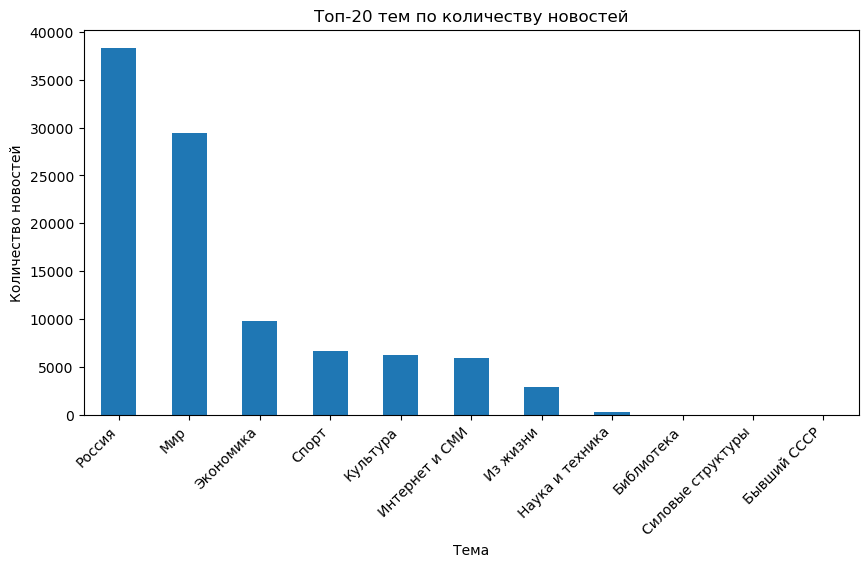

In [ ]:
plt.figure(figsize=(10, 5))
topic_counts.head(20).plot(kind="bar")
plt.title("Топ-20 тем по количеству новостей")
plt.xlabel("Тема")
plt.ylabel("Количество новостей")
plt.xticks(rotation=45, ha="right")
plt.show()

### 7.3 Распределение по времени

Так как будущая система работает с новостным потоком, временное распределение критично для выбора temporal window и стратегии валидации.

In [ ]:
print("Минимальная дата:", clean_df["published_at"].min())
print("Максимальная дата:", clean_df["published_at"].max())

Минимальная дата: 1914-09-16 00:00:00
Максимальная дата: 2004-08-31 00:00:00


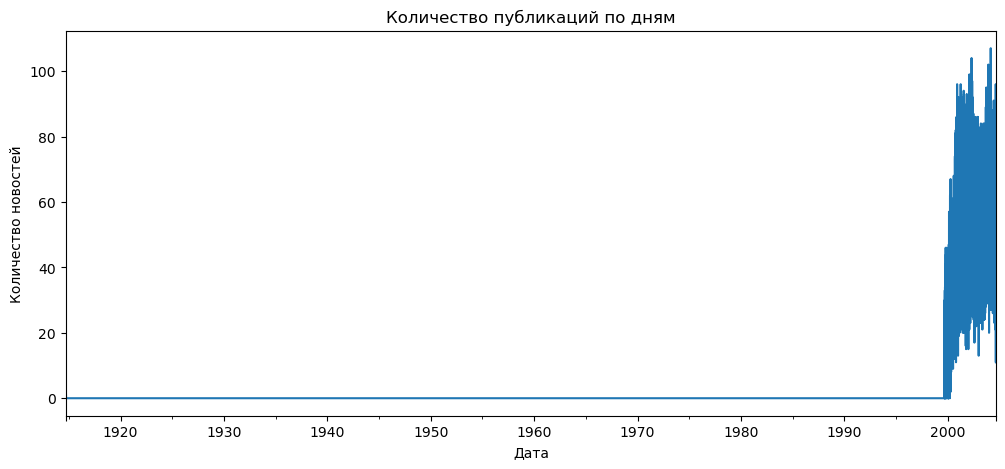

In [ ]:
daily_counts = clean_df.set_index("published_at").resample("D").size()

plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title("Количество публикаций по дням")
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.show()

### 7.4 Корреляции признаков

Это текстовая задача, поэтому классические линейные корреляции на сырых данных имеют ограниченную ценность. Тем не менее полезно проверить технические числовые признаки: длину текста и заголовка.

In [ ]:
numeric_cols = ["text_length", "text_num_words", "title_length", "title_num_words"]
clean_df[numeric_cols].corr()

,text_length,text_num_words,title_length,title_num_words
text_length,1.000000,0.992258,0.140911,0.112832
text_num_words,0.992258,1.000000,0.131602,0.121655
title_length,0.140911,0.131602,1.000000,0.805535
title_num_words,0.112832,0.121655,0.805535,1.000000


Вывод: сильная корреляция между `text_length` и `text_num_words` есть, но не является проблемой. Эти признаки нужны в первую очередь для контроля качества данных, а не как основные признаки модели.

## 8. Нужно ли масштабирование

Для текущей постановки классическое масштабирование признаков не требуется.

Причины:

1. Основной вход модели — текст, а не числовая таблица.
2. Текст будет преобразован в embedding-векторы с помощью sentence-transformer.
3. Для cosine similarity важна не стандартизация через `StandardScaler`, а L2-нормализация embedding-векторов.
4. Для rule-based decision layer масштабирование similarity-признаков не требуется, так как они уже находятся в сопоставимом диапазоне.

Если в дальнейшем поверх similarity-признаков будет обучаться отдельный классификатор, необходимость масштабирования будет зависеть от алгоритма. Например, для Logistic Regression масштабирование может быть полезно, а для деревьев решений — обычно нет.

## 9. Формирование очищенного датасета

На этом этапе сохраняем очищенные данные. Это ещё не финальная novelty-выборка, а базовый датасет новостей, из которого дальше строятся эмбеддинги, кластеры и кандидаты на ручную разметку.

In [ ]:
news_output_cols = [
    "news_id",
    "url",
    "title",
    "text",
    "topic",
    "tags",
    "published_at",
    "text_length",
    "text_num_words",
    "title_length",
    "title_num_words",
    "model_text",
    "model_length",
    "model_num_words"
]

clean_news_path = PREPARED_DIR / "lenta_clean_news.csv"
clean_df[news_output_cols].to_csv(clean_news_path, index=False)
clean_news_path

WindowsPath('E:/ML/Projects/Git/news-flow-analysis/data/prepared/lenta_clean_news.csv')

## 10. Заготовка выборки для разметки novelty

В Lenta.ru нет готовой разметки существенной новизны. Поэтому нужно сформировать пул кандидатов, который потом будет проверяться человеком.

Единица будущей выборки:

```text
previous_news / context → candidate_news → human_label
```

Для MVP используем бинарную разметку:

- `human_label = 1` — кандидат добавляет существенную новую информацию;
- `human_label = 0` — дубль, рерайт или несущественное обновление.

Дополнительно можно сформировать предварительную автоматическую метку `auto_label` на основе простого правила по similarity. Это не финальная разметка и не целевая переменная, а подсказка для разметчика и способ оценить, насколько базовый алгоритм совпадает с человеком.

Ниже формируется небольшой annotation pool на базе TF-IDF по заголовку и началу текста. TF-IDF здесь используется только как технический способ быстро подобрать похожие пары для ручной проверки. В финальной системе similarity-признаки будут считаться поверх эмбеддингов sentence-transformer модели.


In [ ]:
# Настройки формирования пула для разметки
ANNOTATION_SAMPLE_SIZE = 10_000
ANNOTATION_TOPICS = None  # например: ["Россия", "Мир", "Экономика"] или None для всех тем
ANNOTATION_TIME_WINDOW_DAYS = 14
ANNOTATION_MAX_PAIRS = 2_000

# Для TF-IDF берём заголовок + начало текста, чтобы быстро подобрать похожие кандидаты.
TEXT_PREFIX_CHARS = 1000

In [ ]:
def build_annotation_pool(
    df: pd.DataFrame,
    sample_size: int = 10_000,
    time_window_days: int = 14,
    max_pairs: int = 2_000,
    topics=None,
    random_state: int = 42,
) -> pd.DataFrame:
    work = df.copy()

    if topics is not None:
        work = work[work["topic"].isin(topics)]

    # Берём последние новости из сэмпла, чтобы сохранить временную природу задачи.
    work = work.sort_values("published_at").tail(sample_size).reset_index(drop=True)

    work["retrieval_text"] = (
        work["title"].fillna("") + ". " + work["text"].fillna("").str.slice(0, TEXT_PREFIX_CHARS)
    )

    vectorizer = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X = vectorizer.fit_transform(work["retrieval_text"])

    pairs = []
    window = pd.Timedelta(days=time_window_days)

    # Идём по времени: для каждого кандидата ищем похожую новость из прошлого.
    for idx in range(len(work)):
        candidate = work.iloc[idx]
        candidate_time = candidate["published_at"]

        prev_mask = (
            (work.index < idx)
            & (work["published_at"] >= candidate_time - window)
        )

        # Рубрика — грубое ограничение области поиска. Это не story cluster.
        if "topic" in work.columns:
            prev_mask = prev_mask & (work["topic"] == candidate["topic"])

        prev_indices = np.where(prev_mask)[0]
        if len(prev_indices) == 0:
            continue

        sims = cosine_similarity(X[idx], X[prev_indices]).ravel()
        best_local = int(np.argmax(sims))
        best_idx = int(prev_indices[best_local])
        best_sim = float(sims[best_local])

        # Отсекаем совсем непохожие пары, чтобы разметчик не тратил время.
        if best_sim < 0.1:
            continue

        previous = work.iloc[best_idx]
        pairs.append({
            "previous_news_id": previous["news_id"],
            "candidate_news_id": candidate["news_id"],
            "previous_published_at": previous["published_at"],
            "candidate_published_at": candidate["published_at"],
            "time_delta_hours": (candidate["published_at"] - previous["published_at"]).total_seconds() / 3600,
            "topic": candidate["topic"],
            "previous_title": previous["title"],
            "candidate_title": candidate["title"],
            "previous_text": previous["text"],
            "candidate_text": candidate["text"],
            "tfidf_similarity": best_sim,
            # Предварительная автоматическая метка только для ускорения разметки.
            # Здесь используется очень грубое правило: высокая TF-IDF похожесть => вероятный дубль.
            # Финальной разметкой считается human_label, заполненный человеком.
            "auto_label": 0 if best_sim >= 0.75 else np.nan,
            "human_label": np.nan,  # заполняется вручную: 0/1
        })

        if len(pairs) >= max_pairs:
            break

    pool = pd.DataFrame(pairs)

    # Колонка для комментария разметчика помогает разбирать спорные случаи.
    if not pool.empty:
        pool["annotation_comment"] = ""

    return pool

annotation_pool = build_annotation_pool(
    clean_df,
    sample_size=ANNOTATION_SAMPLE_SIZE,
    time_window_days=ANNOTATION_TIME_WINDOW_DAYS,
    max_pairs=ANNOTATION_MAX_PAIRS,
    topics=ANNOTATION_TOPICS,
    random_state=RANDOM_STATE,
)

annotation_pool.shape


(2000, 12)

In [ ]:
annotation_pool[[
    "previous_published_at",
    "candidate_published_at",
    "time_delta_hours",
    "topic",
    "tfidf_similarity",
    "previous_title",
    "candidate_title",
    "auto_label",
    "human_label",
]].head(20)


,previous_published_at,candidate_published_at,time_delta_hours,topic,tfidf_similarity,previous_title,candidate_title,label
0,2004-03-16,2004-03-16,0.0,Россия,0.251806,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",В Архангельске обрушился 9-этажный жилой дом,NaN
1,2004-03-16,2004-03-17,24.0,Россия,0.162973,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",Взрыв в жилом доме Архангельска произошел на втором или третьем этажах,NaN
2,2004-03-16,2004-03-17,24.0,Мир,0.213927,"Полиция идентифицировала ""огайского снайпера""","Предполагаемый ""снайпер из Огайо"" арестован в Лас-Вегасе",NaN
3,2004-03-17,2004-03-17,0.0,Мир,0.246557,К Виталию Калоеву пустили российского адвоката,Спикера парламента Северной Осетии не пускают к больному Виталию Калоеву,NaN
4,2004-03-16,2004-03-17,24.0,Россия,0.101676,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами","""Илим Палп"" выделяет пострадавшим при взрыве в Архангельске два миллиона рублей",NaN
5,2004-03-16,2004-03-17,24.0,Россия,0.427434,"""Бойцы Мовсара Бараева"" угрожают Франции терактами","Французские спецслужбы не узнали исламистов в ""бойцах Мовсара Бараева""",NaN
6,2004-03-17,2004-03-17,0.0,Россия,0.384367,Взрыв в жилом доме Архангельска произошел на втором или третьем этажах,На месте взрыва дома в Архангельске найдена газовая труба со свинченной заглушкой,NaN
7,2004-03-16,2004-03-17,24.0,Россия,0.351722,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",Число погибших в Архангельске выросло до 47 человек. Под завалами могут оставаться еще 20,NaN
8,2004-03-17,2004-03-17,0.0,Россия,0.115837,Госсовет Чечни сделал инспектора Счетной палаты премьером республики,Грызлов возглавил Парламентское собрание союза Белоруссии и России,NaN
9,2004-03-17,2004-03-17,0.0,Мир,0.289929,В центре Багдада взорван отель,Из под обломков взорванной в центре Багдада гостиницы извлечены тела 27 человек,NaN


In [ ]:
annotation_pool_path = PREPARED_DIR / "lenta_novelty_annotation_pool.csv"
annotation_pool.to_csv(annotation_pool_path, index=False)
annotation_pool_path

WindowsPath('E:/ML/Projects/Git/news-flow-analysis/data/prepared/lenta_novelty_annotation_pool.csv')

### Почему это не финальная модель

TF-IDF здесь используется только для формирования кандидатов на ручную разметку. В финальной системе основной ML-компонент — sentence-transformer encoder, который строит семантические embedding-векторы.

После ручной проверки человеком можно будет сформировать финальный датасет:

```text
candidate_news_id
cluster_id / context_id
cluster_similarity
max_recent_similarity
max_significant_similarity
human_label
```

Где similarity-признаки будут рассчитаны уже поверх embedding-модели, а не TF-IDF.

Важно: `auto_label` не считается истинной разметкой. Это предварительная автоматическая подсказка, которую человек может подтвердить или исправить. Целевой переменной для последующей оценки считается `human_label`.


## 11. Оценка качества разметки

Финальная целевая разметка формируется вручную. Для каждой пары/кандидатной новости человек определяет, является ли публикация существенным обновлением внутри сюжета.

Ручная разметка используется как эталонная метка `human_label`, относительно которой в дальнейшем будет оцениваться автоматический алгоритм novelty detection.

Так как разметка новизны частично субъективна, для повышения её качества используются следующие меры:

1. Единая инструкция по разметке.
2. Бинарная постановка задачи на первом этапе:
   - `0` — дубль, рерайт или несущественное обновление;
   - `1` — существенное обновление.
3. Отдельная пометка спорных случаев через поле `needs_review`.
4. Ручной разбор спорных примеров и уточнение правил разметки.
5. При возможности — повторная проверка части выборки вторым человеком.

## Оценка автоматической модели относительно ручной разметки

После получения ручной разметки автоматический алгоритм будет предсказывать метку `predicted_label`. Качество предсказаний оценивается сравнением с `human_label`.

Основные метрики:

- `Precision` — какая доля объектов, которые модель назвала существенными обновлениями, действительно являются существенными;
- `Recall` — какую долю всех существенных обновлений модель смогла найти;
- `F1-score` — гармоническое среднее precision и recall;
- `confusion matrix` — показывает типы ошибок модели.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# для будущего сравнения модели с экспертной оценкой
def compare_with_expert(annotation_df: pd.DataFrame):
    y_true = annotation_df["label"]
    y_pred = annotation_df["predicted_label"]

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

NameError: name 'pd' is not defined

## 12. Валидации

Для новостного потока нельзя ограничиваться случайным train/test split.

Проблемы random split:

1. новости одного сюжета могут попасть одновременно в train и test;
2. это создаёт утечку данных;
3. качество будет завышено относительно реального сценария.

Основная стратегия — temporal split:

```text
train: более ранние публикации
validation/test: более поздние публикации
```

Такой подход соответствует сценарию: система настраивается на исторических данных и применяется к свежим новостям.

In [ ]:
# Temporal split для очищенного корпуса.
# Для финальной размеченной novelty-выборки логика будет такой же.

split_date = clean_df["published_at"].quantile(0.8)

train_df = clean_df[clean_df["published_at"] <= split_date]
test_df = clean_df[clean_df["published_at"] > split_date]

print("split_date:", split_date)
print("train:", train_df.shape)
print("test:", test_df.shape)
print("train dates:", train_df["published_at"].min(), "—", train_df["published_at"].max())
print("test dates:", test_df["published_at"].min(), "—", test_df["published_at"].max())

split_date: 2003-10-09 00:00:00
train: (79693, 11)
test: (19915, 11)
train dates: 1914-09-16 00:00:00 — 2003-10-09 00:00:00
test dates: 2003-10-10 00:00:00 — 2004-08-31 00:00:00


Дополнительно для финальной novelty-выборки можно использовать `GroupKFold` или group split по `cluster_id`, если к моменту обучения уже будут сформированы сюжетные кластеры. Это нужно, чтобы один и тот же сюжет не попадал одновременно в train и test.

## 13. Итоговые артефакты ноутбука

На выходе формируются два файла:

1. `data/prepared/lenta_clean_news.csv` — очищенный датасет новостей Lenta.ru;
2. `data/prepared/lenta_novelty_annotation_pool.csv` — пул кандидатных пар для ручной разметки novelty.
2. `data/prepared/lenta_novelty_annotation_pool_labeled.csv` — пример готовой разметки


Во втором файле предусмотрены поля:

- `label` — метка;
- `annotation_comment` — комментарий для спорных случаев.

Третий файл будет в репозитории как пример разметки, в дальнейшем будет дорабатываться и уточняться для сравнения с готовой моделью.

In [ ]:
print("Очищенный датасет:", clean_news_path)
print("Пул для разметки:", annotation_pool_path)

print("clean_df:", clean_df.shape)
print("annotation_pool:", annotation_pool.shape)

Очищенный датасет: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_clean_news.csv
Пул для разметки: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_novelty_annotation_pool.csv
clean_df: (99636, 15)
annotation_pool: (2000, 12)


## 14. Выводы

1. Данные Lenta.ru подходят для первичного EDA, построения эмбеддингов, настройки кластеризации и формирования пула для разметки.
2. В датасете есть широкие тематические рубрики, но они не равны сюжетным кластерам. Рубрика `topic` может использоваться только как верхний уровень фильтрации.
3. Для будущей модели важны чистые тексты, корректные даты и временной порядок публикаций.
4. Классическое масштабирование признаков на этапе текста не требуется. Для cosine similarity нужна L2-нормализация embedding'ов'.
5. Для понимания корректности работы детекции факта новизны новости требуется отдельная человеческая (экспертная) разметка на достаточно большом датасете, потому что исходный датасет не содержит готовых меток существенной новизны.
6. Для формирования экспертного датасета в дальнейшем следует брать новости из нескольких тематик, и нескольких сформированных (экспертом) кластеров (новостей), чтобы обеспечить более корректную разметку. 
7. Также, формирование кластеров для экспертой (и машинной) оценки должно быть с учетом таймлайна, чтобы имитировать реальный сценарий обработки новостного потока и не допустить утечки между train и test.